In [3]:
# Analysis of a Single Simulation Realization

#This notebook analyzes the output of a single simulation run of the neuronal network model with a fixed target module.

#The simulation is performed using the accompanying C++ code, which generates the following output files:

# - `ActivityInTime.txt`: activity of the eight network modules as a function of time.
# - `NumberOfSynExtInTime.txt`: synaptic and external activity measured separately for the target module and the remaining modules.

#The notebook uses these files to visualize the network activity, module-level activity, power spectrum, external and synaptic contributions, and target-module saliency. It also calculates summary measures, including mean activity and network gain.

#The network structure used in the simulation is supplied separately as an adjacency-list file. Both modular and non-modular network structures are provided in this folder.

#The example output files included with this repository correspond to one simulation realization and allow the analysis pipeline to be tested without rerunning the C++ simulation.

#To analyze a new simulation, place the generated output files in the same directory as this notebook and run the cells sequentially.

In [4]:
# Analysis of a Single Simulation Realization

## 1. Import required packages

## 2. Power-spectrum function

## 3. Load and visualize network activity

## 4. Network structure and activity decomposition

## 5. Summary metrics

In [6]:
# Import numerical and plotting libraries
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from numpy.fft import fft

In [7]:
# =============================================================================
# POWER SPECTRUM
# =============================================================================
# Calculate the single-sided power spectrum of a time series.
#
# The sampling frequency is set to Fs = 1 because the simulation time step
# is one model time step. Therefore, the frequency axis is expressed in
# inverse model time steps.

def PS(rho):
    from numpy.fft import fft
    
    time = np.arange(len(rho))
    L = len(time)
    Fs = 1  # sampling frequency
    
    Y = fft(rho)
    
    # Two-sided power spectrum
    P2 = np.abs(Y / L)
    
    # Single-sided power spectrum
    P1 = P2[0:int(L / 2) + 1]
    
    end = len(P1) - 1
    P1[1:end] = 2 * P1[1:end]
    
    x = np.arange(0, int(L / 2) + 1)
    f = Fs * x / L
    
    frequency = f[1:-2]
    power = P1[1:-2]
    
    return frequency, power

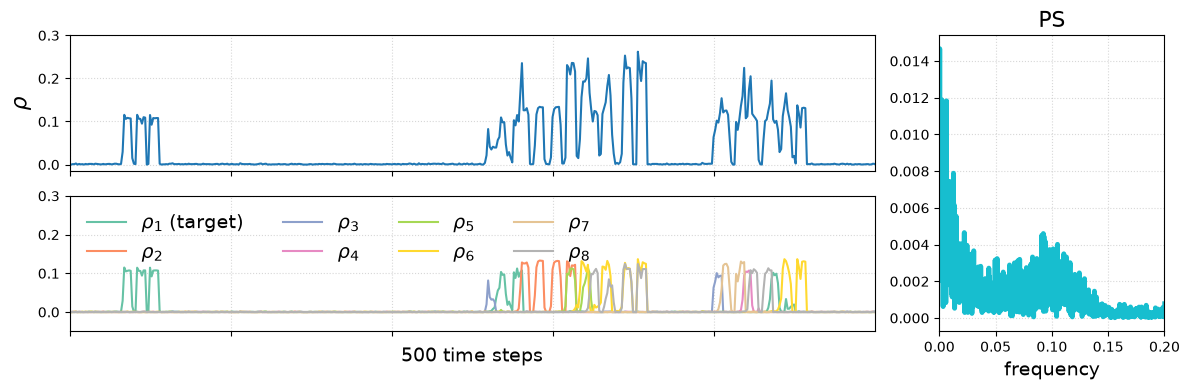

In [8]:
# =============================================================================
# 1. LOAD SIMULATION DATA
# =============================================================================

activity_data_name = 'ActivityInTime.txt'
d = np.loadtxt(activity_data_name)


# =============================================================================
# 2. PLOTTING PARAMETERS
# =============================================================================

fs = 14
gg = 100
lw = 1.5
n = 8

colors = plt.cm.Set2(np.linspace(0, 1, n))

m_names = [
    r'$\rho_1$ (target)', r'$\rho_2$', r'$\rho_3$', r'$\rho_4$',
    r'$\rho_5$', r'$\rho_6$', r'$\rho_7$', r'$\rho_8$'
]


# =============================================================================
# 3. TIME AND MODULE ACTIVITY
# =============================================================================

# Column 0 contains time.
# Columns 1--8 contain the activity of the eight modules.

t = d[:, 0]
t_max = len(t)

left, right = 2000, 2500

# Total network activity: rho_1 + ... + rho_8
Rho = np.sum(d[:, 1:9], axis=1)

# Activity of the target module (module 1)
rho_g = d[:, 1]

# Total activity of the remaining seven modules
rho_oth = np.sum(d[:, 2:9], axis=1)


# =============================================================================
# 4. FIGURE
# =============================================================================
# The figure contains:
#   - total network activity,
#   - activity of individual modules,
#   - power spectrum of total activity.
#
# The first two plots occupy the left part of the figure, while the power
# spectrum occupies the right part.

fig = plt.figure(figsize=(12, 4))
gs = GridSpec(2, 12)


# -----------------------------------------------------------------------------
# Top-left: total network activity
# -----------------------------------------------------------------------------

ax1 = fig.add_subplot(gs[0, :9])

ax1.plot(t, Rho, lw=lw, color='C0')

ax1.set_xlim(left, right)
ax1.set_ylabel(r'$\rho$', fontsize=fs + 2)
ax1.set_xticks(np.arange(0, right, gg))
ax1.grid(linestyle=':', alpha=0.5)


# -----------------------------------------------------------------------------
# Bottom-left: activity of individual modules
# -----------------------------------------------------------------------------

ax_bot = fig.add_subplot(gs[1, :9], sharex=ax1)

for i in range(1, 9):
    R = d[:, i]
    ax_bot.plot(
        t,
        R,
        color=colors[i - 1],
        lw=lw,
        label=m_names[i - 1]
    )

plt.xlim([left, right])

ax_bot.set_xlabel(f'{right-left} time steps', fontsize=fs)
ax_bot.tick_params(labelsize=fs - 4)
ax_bot.grid(linestyle=':', alpha=0.5)

plt.xticks(np.arange(left, right, gg), [])

plt.ylim(-0.05, 0.3)

ax_bot.legend(
    ncol=4,
    loc='upper left',
    fontsize=fs,
    frameon=False
)


# -----------------------------------------------------------------------------
# Right: power spectrum
# -----------------------------------------------------------------------------

ax = fig.add_subplot(gs[:, 9:])

frequency, power = PS(Rho)

plt.plot(
    frequency,
    power,
    color='C9',
    lw=lw + 2
)

plt.xlabel('frequency', fontsize=fs, rotation=0)
plt.title('PS', fontsize=fs + 2)
plt.grid(linestyle=':', alpha=0.5)
plt.xlim(0, 0.2)


plt.tight_layout()

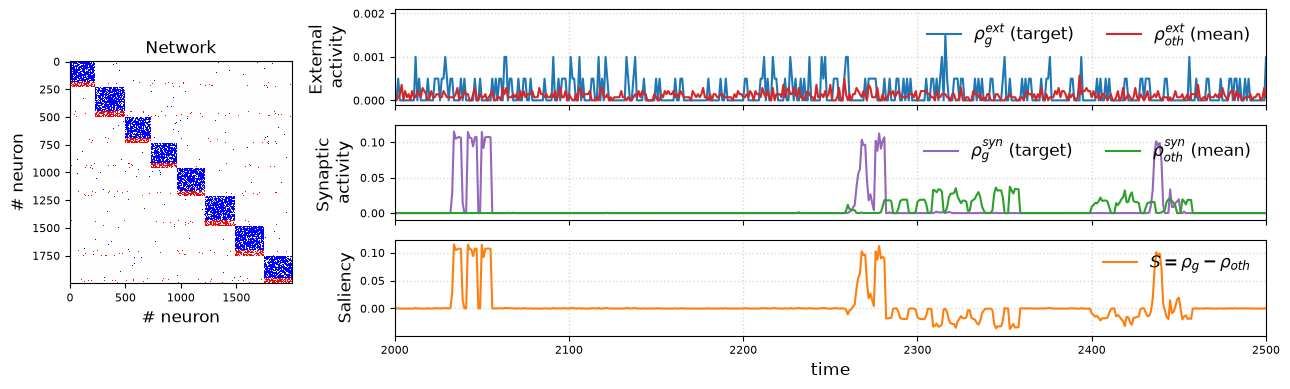

In [11]:
# =============================================================================
# NETWORK STRUCTURE AND ACTIVITY DECOMPOSITION
# =============================================================================

fig = plt.figure(figsize=(13, 4))
gs = GridSpec(3, 12)

fs = 12
ms = 7
lw = 1
alpha = 0.3


# =============================================================================
# 1. LOAD NETWORK STRUCTURE
# =============================================================================

A_data = np.loadtxt('ModularAdjList.txt', dtype=int)

# Number of neurons
N = A_data[0, 0]

# Construct the adjacency matrix from the adjacency-list representation
A = np.zeros((N, N))

for i in np.arange(1, A_data[0, 1] + 1):
    A[A_data[i, 0], A_data[i, 1]] = A_data[i, 2]


# -----------------------------------------------------------------------------
# Network adjacency matrix
# -----------------------------------------------------------------------------

ax = fig.add_subplot(gs[:, :3])

plt.imshow(
    A,
    interpolation='nearest',
    cmap='bwr_r',
    vmin=-0.1,
    vmax=0.1
)

plt.tick_params(axis='both', labelsize=fs - 4)
plt.ylabel('# neuron', fontsize=fs)
plt.xlabel('# neuron', fontsize=fs)
plt.title('Network', fontsize=fs)


# =============================================================================
# 2. LOAD SYNAPTIC AND EXTERNAL ACTIVITY
# =============================================================================

data_syn_ext = np.loadtxt('NumberOfSynExtInTime.txt')

time = data_syn_ext[:, 0]

# Target module
rho_ext_g = data_syn_ext[:, 1] / N
rho_syn_g = data_syn_ext[:, 2] / N

# Remaining seven modules
rho_ext_oth = data_syn_ext[:, 3] / (7.0 * N)
rho_syn_oth = data_syn_ext[:, 4] / (7.0 * N)


# =============================================================================
# 3. EXTERNAL ACTIVITY
# =============================================================================

ax = fig.add_subplot(gs[0, 3:])

plt.grid(
    color='gray',
    alpha=alpha,
    linestyle=':',
    linewidth=lw
)

plt.plot(
    time,
    rho_ext_g,
    ms=ms,
    color='C0',
    label=r'$\rho_g^{ext}$ (target)'
)

plt.plot(
    time,
    rho_ext_oth,
    ms=ms,
    color='C3',
    label=r'$\rho_{oth}^{ext}$ (mean)'
)

plt.tick_params(axis='both', labelsize=fs - 4)
plt.xlim(left, right)

plt.ylabel('External \nactivity', fontsize=fs)

ax.set_xticklabels([])

plt.legend(
    ncol=2,
    fontsize=fs,
    loc='upper right',
    frameon=False
)


# =============================================================================
# 4. SYNAPTIC ACTIVITY
# =============================================================================

ax = fig.add_subplot(gs[1, 3:])

plt.grid(
    color='gray',
    alpha=alpha,
    linestyle=':',
    linewidth=lw
)

plt.plot(
    time,
    rho_syn_g,
    ms=ms,
    color='C4',
    label=r'$\rho_g^{syn}$ (target)'
)

plt.plot(
    time,
    rho_syn_oth,
    ms=ms,
    color='C2',
    label=r'$\rho_{oth}^{syn}$ (mean)'
)

plt.tick_params(axis='both', labelsize=fs - 4)
plt.xlim(left, right)
plt.ylim(-0.01, 0.125)

plt.ylabel('Synaptic \nactivity', fontsize=fs)

ax.set_xticklabels([])

plt.legend(
    ncol=2,
    fontsize=fs,
    loc='upper right',
    frameon=False
)


# =============================================================================
# 5. TARGET-MODULE SALIENCY
# =============================================================================

rho_g = d[:, 1]
rho_oth = np.sum(d[:, 2:9], axis=1) / 7.0

# Saliency measures the difference between target-module activity
# and the mean of combined activity of the other modules.
s = rho_g - rho_oth

ax = fig.add_subplot(gs[2, 3:])

plt.grid(
    color='gray',
    alpha=alpha,
    linestyle=':',
    linewidth=lw
)

plt.plot(
    time,
    s,
    ms=ms,
    color='C1',
    label=r'$S = \rho_g - \rho_{oth}$'
)

plt.tick_params(axis='both', labelsize=fs - 4)
plt.xlim(left, right)

plt.xlabel('time', fontsize=fs)
plt.ylabel('Saliency', fontsize=fs)

plt.legend(
    ncol=1,
    fontsize=fs,
    loc='upper right',
    frameon=False
)


plt.tight_layout()

In [13]:
# =============================================================================
# SUMMARY METRICS
# =============================================================================

# Mean total network activity
mean_Rho = np.mean(Rho)

# Mean activity of target and other modules
mean_rho_g = np.mean(rho_g)
mean_rho_oth = np.mean(rho_oth)

# Mean external activity
mean_rho_ext_g = np.mean(rho_ext_g)
mean_rho_ext_oth = np.mean(rho_ext_oth)

# Mean synaptic activity
mean_rho_syn_g = np.mean(rho_syn_g)
mean_rho_syn_oth = np.mean(rho_syn_oth)

# Mean target-module saliency
mean_saliency = mean_rho_g - mean_rho_oth

# Network gain:
# ratio of mean synaptic activity to mean external activity
# in the target module.
if mean_rho_ext_g != 0:
    G = mean_rho_syn_g / mean_rho_ext_g
else:
    G = 0


# =============================================================================
# PRINT RESULTS
# =============================================================================

print()
print('mean total activity = ', np.round(mean_Rho, 4))
print()

print(
    'mean total activity in target module = ',
    np.round(mean_rho_g, 4)
)
print()

print(
    'mean total activity in other modules = ',
    np.round(mean_rho_oth, 4)
)
print()

print(
    'mean total external-activity in target module = ',
    np.round(mean_rho_ext_g, 4)
)
print()

print(
    'mean total external-activity in other modules = ',
    np.round(mean_rho_ext_oth, 4)
)
print()

print(
    'mean total synaptic-activity in target module = ',
    np.round(mean_rho_syn_g, 4)
)
print()

print(
    'mean total synaptic-activity in other modules = ',
    np.round(mean_rho_syn_oth, 4)
)
print()

print(
    'mean saliency = ',
    np.round(mean_saliency, 4)
)
print()

print(
    'network gain (G) = ',
    np.round(G, 4)
)
print()


mean total activity =  0.0217

mean total activity in target module =  0.0065

mean total activity in other modules =  0.0022

mean total external-activity in target module =  0.0002

mean total external-activity in other modules =  0.0001

mean total synaptic-activity in target module =  0.0063

mean total synaptic-activity in other modules =  0.0021

mean saliency =  0.0043

network gain (G) =  35.4493

